In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

project_path = (
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"
)

results_path = project_path + "/results"

print("Project path:", project_path)
print("Results folder exists:", os.path.exists(results_path))

print("\nSERIAL 30 required files:")

required_files = [
    "realtime_detector_verified_A8.csv",
    "serial29_realtime_summary_A8.csv",
    "realtime_alert_summary_A8.csv"
]

for file in required_files:
    path = os.path.join(results_path, file)
    print(
        "✓" if os.path.exists(path) else "✗",
        file
    )

Project path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Results folder exists: True

SERIAL 30 required files:
✓ realtime_detector_verified_A8.csv
✓ serial29_realtime_summary_A8.csv
✓ realtime_alert_summary_A8.csv


###Load the real-time results

Now we'll load the verified A-8 detection results that our dashboard will use.


In [3]:
import pandas as pd

realtime_path = (
    results_path
    + "/realtime_detector_verified_A8.csv"
)

realtime_df = pd.read_csv(realtime_path)

print("Real-time results loaded.")
print("Rows:", len(realtime_df))
print("\nColumns:")
print(realtime_df.columns.tolist())

print("\nFirst 5 rows:")
print(realtime_df.head())

Real-time results loaded.
Rows: 8326

Columns:
['telemetry_index', 'anomaly_score', 'decision']

First 5 rows:
   telemetry_index  anomaly_score decision
0               49       0.009550   NORMAL
1               50       0.010167   NORMAL
2               51       0.010782   NORMAL
3               52       0.011398   NORMAL
4               53       0.012014   NORMAL


##Load the detection threshold

The dashboard needs to know the threshold so it can draw a clear threshold line on the anomaly-score graph.

In [4]:
summary_path = (
    results_path
    + "/serial29_realtime_summary_A8.csv"
)

summary_df = pd.read_csv(summary_path)

threshold = summary_df["threshold"].iloc[0]

print("Detection threshold:", threshold)

Detection threshold: 0.11613636


##Create the first dashboard graph

Before we install Streamlit, let's first create the main visualization in Colab.

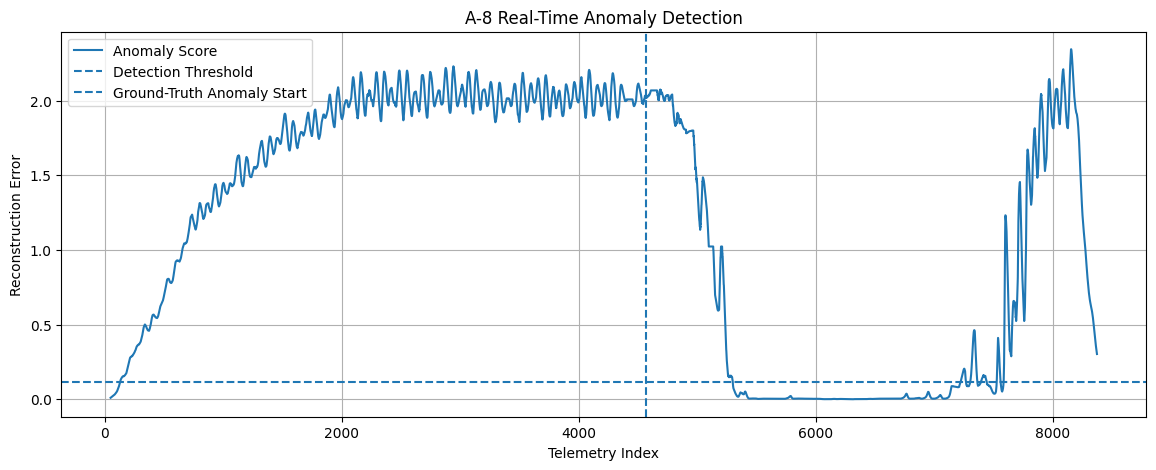

In [5]:
import matplotlib.pyplot as plt

anomaly_start = 4569

plt.figure(figsize=(14, 5))

plt.plot(
    realtime_df["telemetry_index"],
    realtime_df["anomaly_score"],
    label="Anomaly Score"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Detection Threshold"
)

plt.axvline(
    anomaly_start,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

plt.xlabel("Telemetry Index")
plt.ylabel("Reconstruction Error")
plt.title("A-8 Real-Time Anomaly Detection")

plt.legend()
plt.grid(True)
plt.show()

##Add ground-truth labels to the dashboard data

Next, we'll add the actual A-8 anomaly interval to our dataframe. This will let Streamlit later distinguish:

In [6]:
anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
    (
        realtime_df["telemetry_index"] >= anomaly_start
    )
    &
    (
        realtime_df["telemetry_index"] <= anomaly_end
    )
).astype(int)

print("Ground-truth labels added.")

print("\nGround-truth counts:")
print(
    realtime_df["ground_truth"].value_counts()
)

print("\nFirst 5 rows:")
print(
    realtime_df.head()
)

Ground-truth labels added.

Ground-truth counts:
ground_truth
0    4520
1    3806
Name: count, dtype: int64

First 5 rows:
   telemetry_index  anomaly_score decision  ground_truth
0               49       0.009550   NORMAL             0
1               50       0.010167   NORMAL             0
2               51       0.010782   NORMAL             0
3               52       0.011398   NORMAL             0
4               53       0.012014   NORMAL             0


##Add prediction labels

Now we'll convert the detector's "NORMAL" / "ANOMALY" decisions into 0/1 values.

This makes the data easier to use for dashboard metrics and confusion-matrix displays.

In [7]:
realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

print("Prediction labels added.")

print("\nPrediction counts:")
print(
    realtime_df["prediction"].value_counts()
)

print("\nFirst 5 rows:")
print(
    realtime_df.head()
)

Prediction labels added.

Prediction counts:
prediction
1    6144
0    2182
Name: count, dtype: int64

First 5 rows:
   telemetry_index  anomaly_score decision  ground_truth  prediction
0               49       0.009550   NORMAL             0           0
1               50       0.010167   NORMAL             0           0
2               51       0.010782   NORMAL             0           0
3               52       0.011398   NORMAL             0           0
4               53       0.012014   NORMAL             0           0


##Create dashboard summary metrics

Next, we'll calculate TP, TN, FP, FN, precision, recall, and F1 directly from this dataframe.

In [8]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Dashboard Metrics")
print("------------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)
print("Precision      :", round(precision, 6))
print("Recall         :", round(recall, 6))
print("F1 Score       :", round(f1, 6))

Dashboard Metrics
------------------
True Negatives : 81
False Positives: 4439
False Negatives: 2101
True Positives : 1705
Precision      : 0.277507
Recall         : 0.447977
F1 Score       : 0.342714


##Create a dashboard metrics dictionary

This will make the values easy to display later in Streamlit.

In [9]:
dashboard_metrics = {
    "True Negatives": tn,
    "False Positives": fp,
    "False Negatives": fn,
    "True Positives": tp,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Threshold": threshold
}

print("Dashboard metrics prepared:")
print(dashboard_metrics)

Dashboard metrics prepared:
{'True Negatives': np.int64(81), 'False Positives': np.int64(4439), 'False Negatives': np.int64(2101), 'True Positives': np.int64(1705), 'Precision': 0.2775065104166667, 'Recall': 0.4479768786127168, 'F1 Score': 0.342713567839196, 'Threshold': np.float64(0.11613636)}


##Create the confusion matrix

This will prepare the TP, FP, TN, FN values for the dashboard.

In [10]:
confusion_data = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

print("Confusion Matrix:")
print(confusion_data)

Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal                 81               4439
Actual Anomaly              2101               1705


##Create the anomaly score chart data

Now we'll prepare the data that Streamlit will use to display the anomaly score over time.

In [11]:
score_data = realtime_df[
    [
        "telemetry_index",
        "anomaly_score",
        "ground_truth",
        "prediction"
    ]
].copy()

print("Score data prepared.")
print("Rows:", len(score_data))
print("\nColumns:")
print(score_data.columns.tolist())

print("\nFirst 5 rows:")
print(score_data.head())

Score data prepared.
Rows: 8326

Columns:
['telemetry_index', 'anomaly_score', 'ground_truth', 'prediction']

First 5 rows:
   telemetry_index  anomaly_score  ground_truth  prediction
0               49       0.009550             0           0
1               50       0.010167             0           0
2               51       0.010782             0           0
3               52       0.011398             0           0
4               53       0.012014             0           0


##Prepare anomaly regions

Next we'll create a simple column that tells the dashboard whether each telemetry point belongs to the actual anomaly region. This will help us visually mark the ground-truth anomaly on the graph.

In [12]:
score_data["actual_anomaly"] = score_data["ground_truth"].map(
    {
        0: "Normal",
        1: "Anomaly"
    }
)

score_data["detected_anomaly"] = score_data["prediction"].map(
    {
        0: "Normal",
        1: "Anomaly"
    }
)

print("Anomaly regions prepared.")

print("\nActual labels:")
print(score_data["actual_anomaly"].value_counts())

print("\nDetected labels:")
print(score_data["detected_anomaly"].value_counts())

Anomaly regions prepared.

Actual labels:
actual_anomaly
Normal     4520
Anomaly    3806
Name: count, dtype: int64

Detected labels:
detected_anomaly
Anomaly    6144
Normal     2182
Name: count, dtype: int64


##Create the dashboard folder

We'll keep the Streamlit application separate from the research notebooks.

In [13]:
import os

dashboard_path = project_path + "/dashboard"

os.makedirs(dashboard_path, exist_ok=True)

print("Dashboard folder:", dashboard_path)
print("Folder exists:", os.path.exists(dashboard_path))

Dashboard folder: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard
Folder exists: True


##Check Streamlit

Before creating the app, let's check whether Streamlit is already installed in your Colab environment.

In [14]:
import importlib.util

streamlit_installed = (
    importlib.util.find_spec("streamlit") is not None
)

print("Streamlit installed:", streamlit_installed)

Streamlit installed: False


## Now we Install Streamlit

In [15]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 105.9 MB/s eta 0:00:00


###Verify Streamlit

In [16]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.64.0


##Create the Streamlit app

In [17]:
app_path = dashboard_path + "/app.py"

app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Spacecraft Anomaly Detection",
    layout="wide"
)

st.title("Spacecraft Telemetry Anomaly Detection")

st.write(
    "Real-time anomaly detection results for spacecraft channel A-8 "
    "using an LSTM Autoencoder."
)

results_path = (
    "/content/drive/MyDrive/"
    "Spacecraft-Anomaly-Detection/results"
)

realtime_path = (
    results_path +
    "/realtime_detector_verified_A8.csv"
)

summary_path = (
    results_path +
    "/serial29_realtime_summary_A8.csv"
)

realtime_df = pd.read_csv(realtime_path)
summary_df = pd.read_csv(summary_path)

threshold = summary_df["threshold"].iloc[0]

anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
    (
        realtime_df["telemetry_index"] >= anomaly_start
    )
    &
    (
        realtime_df["telemetry_index"] <= anomaly_end
    )
).astype(int)

realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Precision",
    f"{precision:.3f}"
)

col2.metric(
    "Recall",
    f"{recall:.3f}"
)

col3.metric(
    "F1 Score",
    f"{f1:.3f}"
)

col4.metric(
    "Threshold",
    f"{threshold:.4f}"
)

st.subheader("Confusion Matrix")

confusion_data = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

st.dataframe(confusion_data)

st.subheader("Anomaly Score")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    realtime_df["telemetry_index"],
    realtime_df["anomaly_score"],
    label="Anomaly Score"
)

ax.axhline(
    threshold,
    linestyle="--",
    label="Detection Threshold"
)

ax.axvline(
    anomaly_start,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

ax.set_xlabel("Telemetry Index")
ax.set_ylabel("Reconstruction Error")
ax.set_title("A-8 Real-Time Anomaly Detection")

ax.legend()
ax.grid(True)

st.pyplot(fig)

st.subheader("Detection Summary")

st.write(
    f"Total windows evaluated: {len(realtime_df)}"
)

st.write(
    f"Detected anomaly windows: {int(realtime_df['prediction'].sum())}"
)

st.write(
    f"Ground-truth anomaly windows: {int(realtime_df['ground_truth'].sum())}"
)
'''

with open(app_path, "w") as file:
    file.write(app_code)

print("Streamlit app created.")
print("Path:", app_path)

Streamlit app created.
Path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py


##Validate app.py

In [18]:
import py_compile

py_compile.compile(
    app_path,
    doraise=True
)

print("app.py syntax check: PASSED")

app.py syntax check: PASSED


##Start Streamlit server

In [19]:
import subprocess
import time

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port",
        "8501",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Streamlit server started.")
print("Process ID:", streamlit_process.pid)

Streamlit server started.
Process ID: 1461


##Install pyngrok

Now we need to make that local server accessible from my browser. For Colab, we'll use a tunnel.

In [20]:
!pip install -q pyngrok

##Start the tunnel

In [21]:
from google.colab import output

dashboard_url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("Streamlit Dashboard URL:")
print(dashboard_url)

Streamlit Dashboard URL:
https://8501-m-s-kkb-use4c0-2f2gwci7b38gq-c.us-east4-0.prod.colab.dev


##let's check whether Streamlit is still running.

In [22]:
import requests

response = requests.get(
    "http://localhost:8501"
)

print("Status code:", response.status_code)
print("Response length:", len(response.text))
print("\nFirst 500 characters:")
print(response.text[:500])

Status code: 200
Response length: 7260

First 500 characters:
<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or im


In [23]:
print(
    "Streamlit running:",
    streamlit_process.poll() is None
)

print(
    "Process ID:",
    streamlit_process.pid
)

Streamlit running: True
Process ID: 1461


##Restart Streamlit


In [24]:
import subprocess
import time

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port",
        "8501",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(3)

print(
    "Streamlit running:",
    streamlit_process.poll() is None
)

print(
    "Process ID:",
    streamlit_process.pid
)

Streamlit running: False
Process ID: 1616


##Test the app

In [25]:
import requests

response = requests.get(
    "http://localhost:8501"
)

print("Status code:", response.status_code)
print("Streamlit server is responding:", response.ok)

Status code: 200
Streamlit server is responding: True


In [26]:
from google.colab import output

dashboard_url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("Fresh Streamlit Dashboard URL:")
print(dashboard_url)

Fresh Streamlit Dashboard URL:
https://8501-m-s-kkb-use4c0-2f2gwci7b38gq-c.us-east4-0.prod.colab.dev


##Create a lightweight dashboard

In [27]:
app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

st.set_page_config(
    page_title="Spacecraft Anomaly Detection",
    layout="wide"
)

st.title("🚀 Spacecraft Telemetry Anomaly Detection")

st.write(
    "Real-time anomaly detection results for spacecraft channel A-8 "
    "using an LSTM Autoencoder."
)

results_path = (
    "/content/drive/MyDrive/"
    "Spacecraft-Anomaly-Detection/results"
)

realtime_df = pd.read_csv(
    results_path +
    "/realtime_detector_verified_A8.csv"
)

summary_df = pd.read_csv(
    results_path +
    "/serial29_realtime_summary_A8.csv"
)

threshold = float(
    summary_df["threshold"].iloc[0]
)

anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
    (realtime_df["telemetry_index"] >= anomaly_start)
    &
    (realtime_df["telemetry_index"] <= anomaly_end)
).astype(int)

realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

st.subheader("Model Performance")

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Precision",
    f"{precision:.3f}"
)

col2.metric(
    "Recall",
    f"{recall:.3f}"
)

col3.metric(
    "F1 Score",
    f"{f1:.3f}"
)

col4.metric(
    "Threshold",
    f"{threshold:.4f}"
)

st.subheader("Confusion Matrix")

confusion_data = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=[
        "Actual Normal",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Normal",
        "Predicted Anomaly"
    ]
)

st.dataframe(
    confusion_data,
    use_container_width=True
)

st.subheader("A-8 Anomaly Score")

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    realtime_df["telemetry_index"],
    realtime_df["anomaly_score"],
    linewidth=1
)

ax.axhline(
    threshold,
    linestyle="--",
    label="Detection Threshold"
)

ax.axvline(
    anomaly_start,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

ax.set_xlabel("Telemetry Index")
ax.set_ylabel("Reconstruction Error")
ax.set_title(
    "A-8 Real-Time Anomaly Detection"
)

ax.legend()
ax.grid(True)

st.pyplot(fig)

st.subheader("Detection Summary")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Windows Evaluated",
    f"{len(realtime_df):,}"
)

col2.metric(
    "Detected Anomaly Windows",
    f"{int(y_pred.sum()):,}"
)

col3.metric(
    "Ground-Truth Anomaly Windows",
    f"{int(y_true.sum()):,}"
)
'''

with open(app_path, "w") as file:
    file.write(app_code)

print("Lightweight Streamlit app created.")
print("Path:", app_path)

Lightweight Streamlit app created.
Path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py


In [28]:
print(
    "Streamlit running:",
    streamlit_process.poll() is None
)

import requests

response = requests.get("http://localhost:8501")

print("Server status:", response.status_code)
print("Server responding:", response.ok)

Streamlit running: False
Server status: 200
Server responding: True


In [29]:
from google.colab import output

dashboard_url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("Dashboard URL:")
print(dashboard_url)

Dashboard URL:
https://8501-m-s-kkb-use4c0-2f2gwci7b38gq-c.us-east4-0.prod.colab.dev


In [30]:
import subprocess
import time
import requests

# Stop the current Streamlit process
if streamlit_process.poll() is None:
    streamlit_process.terminate()
    time.sleep(2)

# Start Streamlit with Colab-friendly settings
log_file = open("/tmp/streamlit.log", "w")

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port",
        "8501",
        "--server.headless",
        "true",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Streamlit running:", streamlit_process.poll() is None)

response = requests.get("http://localhost:8501")

print("Server status:", response.status_code)
print("HTML received:", len(response.text), "characters")

log_file.flush()

with open("/tmp/streamlit.log", "r") as f:
    logs = f.read()

print("\nStreamlit log:")
print(logs[-3000:])

Streamlit running: True
Server status: 200
HTML received: 7260 characters

Streamlit log:





In [31]:
import requests

response = requests.get("http://localhost:8501")
html = response.text

print("HTML length:", len(html))

checks = {
    "Streamlit detected": "streamlit" in html.lower(),
    "App title present": "Spacecraft" in html,
    "Main script present": "_stcore" in html,
    "WebSocket reference present": "WebSocket" in html
}

for name, result in checks.items():
    print(f"{name}: {result}")

print("\nFirst 1000 characters:\n")
print(html[:1000])

HTML length: 7260
Streamlit detected: True
App title present: False
Main script present: False
WebSocket reference present: False

First 1000 characters:

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" /

In [32]:
import requests

response = requests.get(
    "http://localhost:8501",
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("Server:", response.headers.get("server"))
print("Streamlit version header:", response.headers.get("x-streamlit-version"))

print("\nImportant HTML markers:")

markers = [
    '<html',
    'streamlit',
    '_stcore',
    'Spacecraft Telemetry',
    'Spacecraft Anomaly'
]

for marker in markers:
    print(f"{marker}: {marker.lower() in response.text.lower()}")

Status: 200
Content-Type: text/html; charset=utf-8
Server: uvicorn
Streamlit version header: None

Important HTML markers:
<html: True
streamlit: True
_stcore: False
Spacecraft Telemetry: False
Spacecraft Anomaly: False


In [33]:
import time

# Restart Streamlit with WebSocket-friendly settings
if streamlit_process.poll() is None:
    streamlit_process.terminate()
    time.sleep(2)

log_file = open("/tmp/streamlit.log", "w")

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false",
        "--browser.serverAddress",
        "localhost"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print(
    "Streamlit running:",
    streamlit_process.poll() is None
)

print("\nServer test:")

response = requests.get(
    "http://localhost:8501"
)

print("Status:", response.status_code)
print("HTML length:", len(response.text))

log_file.flush()

with open("/tmp/streamlit.log", "r") as f:
    print("\nLog:")
    print(f.read()[-2000:])

Streamlit running: False

Server test:
Status: 200
HTML length: 7260

Log:


2026-09-22 05:45:59.635 Port 8501 is not available



In [34]:
from google.colab import output

dashboard_url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("Fresh Dashboard URL:")
print(dashboard_url)

Fresh Dashboard URL:
https://8501-m-s-kkb-use4c0-2f2gwci7b38gq-c.us-east4-0.prod.colab.dev


In [35]:
!pip install -q websocket-client

import websocket

try:
    ws = websocket.create_connection(
        "ws://localhost:8501/_stcore/stream",
        subprotocols=["streamlit"],
        timeout=5
    )

    print("WebSocket connection: SUCCESS")
    print("Protocol:", ws.sock and ws.sock.version)

    ws.close()

except Exception as e:
    print("WebSocket connection: FAILED")
    print(type(e).__name__)
    print(str(e))

WebSocket connection: SUCCESS
WebSocket connection: FAILED
AttributeError
'socket' object has no attribute 'version'


In [36]:
import websocket

proxy_ws_url = dashboard_url.replace(
    "https://",
    "wss://"
) + "/_stcore/stream"

print("Testing external proxy WebSocket...")

try:
    ws = websocket.create_connection(
        proxy_ws_url,
        subprotocols=["streamlit"],
        timeout=10
    )

    print("External proxy WebSocket: SUCCESS")

    ws.close()

except Exception as e:
    print("External proxy WebSocket: FAILED")
    print(type(e).__name__)
    print(str(e))

Testing external proxy WebSocket...
External proxy WebSocket: FAILED
WebSocketBadStatusException
Handshake status 404 Not Found -+-+- {'cache-control': 'no-cache, no-store, max-age=0, must-revalidate', 'content-length': '0', 'date': 'Tue, 22 Sep 2026 05:46:10 GMT', 'expires': 'Mon, 01 Jan 1990 00:00:00 GMT', 'pragma': 'no-cache', 'via': '1.1 google', 'sec-websocket-accept': 'SZDF0+OPBq8lWqptx8yznit0VdE=', 'alt-svc': 'h3=":443"; ma=2592000', 'connection': 'close'} -+-+- None


In [37]:
import subprocess
import time
import os

# Download cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

print("cloudflared installed.")

# Start tunnel
cloudflared_process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8501"
    ],
    stdout=open("/tmp/cloudflared.log", "w"),
    stderr=subprocess.STDOUT
)

time.sleep(8)

print("Cloudflare tunnel running:",
      cloudflared_process.poll() is None)

with open("/tmp/cloudflared.log", "r") as f:
    logs = f.read()

print("\nCloudflare Tunnel Log:")
print(logs[-3000:])

cloudflared installed.
Cloudflare tunnel running: True

Cloudflare Tunnel Log:
2026-09-22T05:46:10Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-22T05:46:10Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T05:46:14Z INF +--------------------------------------------------------------------------------------------+
2026-09-22T05:46:14Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
20

## 30.2 create the improved layout version of app.py.

In [38]:
 app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

st.set_page_config(
    page_title="Spacecraft Anomaly Detection",
    page_icon="🚀",
    layout="wide"
)

results_path = (
    "/content/drive/MyDrive/"
    "Spacecraft-Anomaly-Detection/results"
)

realtime_df = pd.read_csv(
    results_path +
    "/realtime_detector_verified_A8.csv"
)

summary_df = pd.read_csv(
    results_path +
    "/serial29_realtime_summary_A8.csv"
)

threshold = float(
    summary_df["threshold"].iloc[0]
)

anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
    (realtime_df["telemetry_index"] >= anomaly_start)
    &
    (realtime_df["telemetry_index"] <= anomaly_end)
).astype(int)

realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

st.title("🚀 Spacecraft Telemetry Anomaly Detection")

st.caption(
    "Research dashboard for NASA spacecraft channel A-8 "
    "using an LSTM Autoencoder."
)

st.divider()

st.header("Model Performance")

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Precision",
    f"{precision:.3f}"
)

col2.metric(
    "Recall",
    f"{recall:.3f}"
)

col3.metric(
    "F1 Score",
    f"{f1:.3f}"
)

col4.metric(
    "Threshold",
    f"{threshold:.4f}"
)

st.divider()

st.header("Detection Overview")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Telemetry Windows",
    f"{len(realtime_df):,}"
)

col2.metric(
    "Ground-Truth Anomalies",
    f"{int(y_true.sum()):,}"
)

col3.metric(
    "Detected Anomalies",
    f"{int(y_pred.sum()):,}"
)

st.divider()

st.header("A-8 Anomaly Score")

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    realtime_df["telemetry_index"],
    realtime_df["anomaly_score"],
    linewidth=1,
    label="Anomaly Score"
)

ax.axhline(
    threshold,
    linestyle="--",
    label="Detection Threshold"
)

ax.axvline(
    anomaly_start,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

ax.axvline(
    anomaly_end,
    linestyle="--",
    label="Ground-Truth Anomaly End"
)

ax.set_xlabel("Telemetry Index")
ax.set_ylabel("Reconstruction Error")
ax.set_title("A-8 Real-Time Anomaly Detection")

ax.legend()
ax.grid(True)

st.pyplot(fig)

st.divider()

st.header("Confusion Matrix")

confusion_data = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=[
        "Actual Normal",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Normal",
        "Predicted Anomaly"
    ]
)

st.dataframe(
    confusion_data,
    use_container_width=True
)

st.divider()

st.header("Detection Summary")

summary_col1, summary_col2 = st.columns(2)

with summary_col1:
    st.write(
        f"**Anomaly interval:** "
        f"{anomaly_start} – {anomaly_end}"
    )

    st.write(
        f"**Anomaly windows:** "
        f"{int(y_true.sum()):,}"
    )

with summary_col2:
    st.write(
        f"**Detected anomaly windows:** "
        f"{int(y_pred.sum()):,}"
    )

    st.write(
        f"**False positives:** "
        f"{fp:,}"
    )
'''

with open(app_path, "w") as file:
    file.write(app_code)

print("SERIAL 30.2 layout created.")
print("Updated:", app_path)

SERIAL 30.2 layout created.
Updated: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py


In [39]:
print(
    "Cloudflare tunnel running:",
    cloudflared_process.poll() is None
)

if cloudflared_process.poll() is None:
    print("Tunnel process is active.")
else:
    print("Tunnel process has stopped.")

Cloudflare tunnel running: True
Tunnel process is active.


In [40]:
import subprocess
import time

cloudflared_process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8501"
    ],
    stdout=open("/tmp/cloudflared.log", "w"),
    stderr=subprocess.STDOUT
)

time.sleep(8)

print(
    "Cloudflare tunnel running:",
    cloudflared_process.poll() is None
)

with open("/tmp/cloudflared.log", "r") as f:
    logs = f.read()

print("\nTunnel URL:")

for line in logs.splitlines():
    if "trycloudflare.com" in line:
        print(line.strip())

Cloudflare tunnel running: True

Tunnel URL:
2026-09-22T05:46:19Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T05:46:23Z INF |  https://buying-northwest-vocals-soup.trycloudflare.com                                    |


In [41]:
import requests

print(
    "Streamlit running:",
    streamlit_process.poll() is None
)

print(
    "Cloudflare tunnel running:",
    cloudflared_process.poll() is None
)

try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=5
    )

    print(
        "Local Streamlit status:",
        response.status_code
    )

except Exception as e:
    print(
        "Local Streamlit connection: FAILED"
    )
    print(type(e).__name__, str(e))

Streamlit running: False
Cloudflare tunnel running: True
Local Streamlit status: 200


In [42]:
import subprocess
import time

streamlit_log = open(
    "/tmp/streamlit.log",
    "w"
)

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false"
    ],
    stdout=streamlit_log,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(6)

print(
    "Streamlit running:",
    streamlit_process.poll() is None
)

try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=5
    )

    print(
        "Local Streamlit status:",
        response.status_code
    )

except Exception as e:
    print(
        "Local connection failed:",
        type(e).__name__,
        str(e)
    )

streamlit_log.flush()

with open("/tmp/streamlit.log", "r") as f:
    print("\nStreamlit log:")
    print(f.read()[-2000:])

Streamlit running: False
Local Streamlit status: 200

Streamlit log:


2026-09-22 05:46:31.548 Port 8501 is not available



In [43]:
import time

time.sleep(2)

with open("/tmp/streamlit.log", "r") as f:
    logs = f.read()

print("Latest Streamlit log:")
print(logs[-5000:])

Latest Streamlit log:


2026-09-22 05:46:31.548 Port 8501 is not available



# new in this chat

In [44]:
import requests

url = "http://localhost:8501"

try:
    response = requests.get(url, timeout=10)

    print("Status code:", response.status_code)
    print("Response length:", len(response.text))
    print("\nFirst 500 characters:\n")
    print(response.text[:500])

except Exception as e:
    print("ERROR:", e)

Status code: 200
Response length: 7260

First 500 characters:

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or im


In [45]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[s]treamlit'"],
    capture_output=True,
    text=True
)

print(result.stdout)

root        1461  4.3  0.5 676532 75384 ?        Sl   05:45   0:03 /usr/bin/python3 /usr/local/bin/streamlit run /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py --server.port 8501 --server.headless true



In [46]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps -p 1175 -o pid,etime,cmd"],
    capture_output=True,
    text=True
)

print(result.stdout)

    PID     ELAPSED CMD



In [47]:
import os

print("Dashboard files:")
for file in sorted(os.listdir(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard"
)):
    print(" -", file)

Dashboard files:
 - __pycache__
 - app.py


In [48]:
import ast

app_path = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"

try:
    with open(app_path, "r", encoding="utf-8") as f:
        code = f.read()

    ast.parse(code)

    print("app.py syntax check: PASS")
    print("File size:", len(code), "characters")

except SyntaxError as e:
    print("app.py syntax check: FAILED")
    print(e)

except Exception as e:
    print("ERROR:", e)

app.py syntax check: PASS
File size: 3296 characters


In [49]:
app_path = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"

with open(app_path, "r", encoding="utf-8") as f:
    code = f.read()

print(code)


import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
   precision_score,
   recall_score,
   f1_score,
   confusion_matrix
)

st.set_page_config(
   page_title="Spacecraft Anomaly Detection",
   page_icon="🚀",
   layout="wide"
)

results_path = (
   "/content/drive/MyDrive/"
   "Spacecraft-Anomaly-Detection/results"
)

realtime_df = pd.read_csv(
   results_path +
   "/realtime_detector_verified_A8.csv"
)

summary_df = pd.read_csv(
   results_path +
   "/serial29_realtime_summary_A8.csv"
)

threshold = float(
   summary_df["threshold"].iloc[0]
)

anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
   (realtime_df["telemetry_index"] >= anomaly_start)
   &
   (realtime_df["telemetry_index"] <= anomaly_end)
).astype(int)

realtime_df["prediction"] = (
   realtime_df["decision"] == "ANOMALY"
).astype(int)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
   y

In [50]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

results_path = (
    "/content/drive/MyDrive/"
    "Spacecraft-Anomaly-Detection/results"
)

realtime_df = pd.read_csv(
    results_path + "/realtime_detector_verified_A8.csv"
)

summary_df = pd.read_csv(
    results_path + "/serial29_realtime_summary_A8.csv"
)

threshold = float(summary_df["threshold"].iloc[0])

anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
    (realtime_df["telemetry_index"] >= anomaly_start)
    &
    (realtime_df["telemetry_index"] <= anomaly_end)
).astype(int)

realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Data loading: PASS")
print("Rows:", len(realtime_df))
print("Columns:", list(realtime_df.columns))
print("Threshold:", threshold)

print("\nConfusion Matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nMetrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Data loading: PASS
Rows: 8326
Columns: ['telemetry_index', 'anomaly_score', 'decision', 'ground_truth', 'prediction']
Threshold: 0.11613636

Confusion Matrix:
TN: 81
FP: 4439
FN: 2101
TP: 1705

Metrics:
Precision: 0.2775065104166667
Recall: 0.4479768786127168
F1: 0.342713567839196


In [51]:
import os

test_app = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/test_app.py"

with open(test_app, "w", encoding="utf-8") as f:
    f.write("""
import streamlit as st

st.set_page_config(
    page_title="Streamlit Test",
    page_icon="🚀"
)

st.title("🚀 Streamlit Test")
st.success("The Streamlit frontend is working.")
st.write("If you can see this page, the browser/frontend connection is working.")
""")

print("Test app created:", os.path.exists(test_app))
print("Path:", test_app)

Test app created: True
Path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/test_app.py


In [52]:
import subprocess
import time

test_app = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/test_app.py"

test_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        test_app,
        "--server.port",
        "8502",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Test Streamlit process started.")
print("PID:", test_process.pid)
print("Port: 8502")

Test Streamlit process started.
PID: 2615
Port: 8502


In [53]:
import requests

url = "http://localhost:8502"

try:
    response = requests.get(url, timeout=10)

    print("Status code:", response.status_code)
    print("Response length:", len(response.text))
    print("Contains Streamlit:", "streamlit" in response.text.lower())

except Exception as e:
    print("ERROR:", e)

Status code: 200
Response length: 7260
Contains Streamlit: True


In [55]:
from google.colab import output

output.serve_kernel_port_as_iframe(8502)

<IPython.core.display.Javascript object>

In [56]:
from google.colab import output

proxy_url = output.eval_js(
    "google.colab.kernel.proxyPort(8502)"
)

print("Proxy URL:")
print(proxy_url)

Proxy URL:
https://8502-m-s-kkb-use4c0-2f2gwci7b38gq-c.us-east4-0.prod.colab.dev


In [60]:
import subprocess

result = subprocess.run(
    [
        "bash",
        "-c",
        "streamlit config show | grep -E '^(\\[server\\]|headless|port|enableCORS|enableXsrfProtection|browser|address)'"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

[server]



In [61]:
import subprocess

result = subprocess.run(
    ["streamlit", "config", "show"],
    capture_output=True,
    text=True
)

for line in result.stdout.splitlines():
    if any(x in line.lower() for x in [
        "headless",
        "port",
        "enablecors",
        "enablexsrf",
        "address"
    ]):
        print(line)

# When true, hides the built-in controls for exporting data from
# components that support it:
# This only hides the built-in export and copy controls. It does not
# disableDataExport = false
# or when the execution environment will stop supporting it in the future.
# False (the default), Streamlit reports fast proxy values for those
# headless = true
# Whether to show a terminal prompt for the user's email address when
# `server.headless=True`, Streamlit will not show this prompt.
# The address where the server will listen for client and browser
# Use this if you want to bind the server to a specific address.
# If set, the server will only be accessible from this address, and not from
# address =
# The port where the server will listen for browser connections.
# port = 8501
# Enables support for Cross-Origin Resource Sharing (CORS) protection,
# option for you when `server.enableXsrfProtection` is `True`.
# enableCORS = true
# If CORS protection is enabled (`server.enableCORS=True`), 

In [62]:
import requests

for port in [8501, 8502]:
    url = f"http://localhost:{port}/_stcore/health"

    try:
        r = requests.get(url, timeout=10)
        print(f"Port {port}:")
        print("  Status:", r.status_code)
        print("  Response:", r.text)
    except Exception as e:
        print(f"Port {port}: ERROR:", e)

Port 8501:
  Status: 200
  Response: ok
Port 8502: ERROR: HTTPConnectionPool(host='localhost', port=8502): Read timed out. (read timeout=10)


In [63]:
import requests

url = "http://localhost:8501/_stcore/health"

r = requests.get(url, timeout=10)

print("Status:", r.status_code)
print("Response:", r.text)
print("Content-Type:", r.headers.get("content-type"))

Status: 200
Response: ok
Content-Type: text/plain; charset=utf-8


In [64]:
import requests

r = requests.get(
    "http://localhost:8501",
    timeout=10
)

print("Status:", r.status_code)

for key, value in r.headers.items():
    if key.lower() in [
        "content-type",
        "server",
        "x-frame-options",
        "content-security-policy",
        "access-control-allow-origin"
    ]:
        print(f"{key}: {value}")

Status: 200
server: uvicorn
content-type: text/html; charset=utf-8


In [65]:
import socket

host = "localhost"
port = 8501

sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.settimeout(5)

try:
    result = sock.connect_ex((host, port))

    if result == 0:
        print(f"TCP connection to {host}:{port}: PASS")
    else:
        print(f"TCP connection to {host}:{port}: FAILED")
        print("Error code:", result)

finally:
    sock.close()

TCP connection to localhost:8501: PASS


In [66]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[c]loudflared'"],
    capture_output=True,
    text=True
)

if result.stdout.strip():
    print("Cloudflare tunnel process:")
    print(result.stdout)
else:
    print("Cloudflare tunnel process: NOT RUNNING")

Cloudflare tunnel process:
root        1789  0.0  0.2 1295060 37736 ?       Sl   05:46   0:01 /content/cloudflared tunnel --url http://127.0.0.1:8501
root        1848  0.0  0.2 1294804 37944 ?       Sl   05:46   0:01 /content/cloudflared tunnel --url http://127.0.0.1:8501



In [67]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[c]loudflared' | sed 's/.*tunnel --url //'"],
    capture_output=True,
    text=True
)

print("Tunnel target:")
print(result.stdout)

Tunnel target:
http://127.0.0.1:8501
http://127.0.0.1:8501



In [68]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[c]loudflared'"],
    capture_output=True,
    text=True
)

print(result.stdout)

root        1789  0.0  0.2 1295060 37736 ?       Sl   05:46   0:01 /content/cloudflared tunnel --url http://127.0.0.1:8501
root        1848  0.0  0.2 1294804 37944 ?       Sl   05:46   0:01 /content/cloudflared tunnel --url http://127.0.0.1:8501



In [69]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "for pid in 1789 1848; do echo \"===== PID $pid =====\"; cat /proc/$pid/fd/1 2>/dev/null | tail -30; done"],
    capture_output=True,
    text=True
)

print(result.stdout)

===== PID 1789 =====
2026-09-22T05:46:23Z INF ICMP proxy will use 172.28.0.12 as source for IPv4
2026-09-22T05:46:23Z INF ICMP proxy will use ::1 in zone lo as source for IPv6
2026/09/22 05:46:23 failed to sufficiently increase receive buffer size (was: 208 kiB, wanted: 7168 kiB, got: 416 kiB). See https://github.com/quic-go/quic-go/wiki/UDP-Buffer-Sizes for details.
2026-09-22T05:46:23Z INF ICMP proxy will use 172.28.0.12 as source for IPv4
2026-09-22T05:46:23Z INF ICMP proxy will use ::1 in zone lo as source for IPv6
2026-09-22T05:46:23Z INF Starting metrics server on 127.0.0.1:20242/metrics
2026-09-22T05:46:23Z INF Tunnel connection curve preferences: [X25519MLKEM768 CurveID(65074) CurveP256] connIndex=0 event=0 ip=198.41.192.77
2026-09-22T05:46:23Z INF Registered tunnel connection connIndex=0 connection=c46f5a8a-4e6b-49b8-b79d-1b9651f3e705 event=0 ip=198.41.192.77 location=iad03 protocol=quic
2026-09-22T05:46:29Z INF +----------------------------------------------------------------

In [70]:
import subprocess

for pid in [1789, 1848]:
    print(f"\n===== PID {pid} STDERR =====")

    result = subprocess.run(
        ["bash", "-c", f"cat /proc/{pid}/fd/2 2>/dev/null | tail -50"],
        capture_output=True,
        text=True
    )

    print(result.stdout)


===== PID 1789 STDERR =====
2026-09-22T05:46:19Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-22T05:46:19Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T05:46:23Z INF +--------------------------------------------------------------------------------------------+
2026-09-22T05:46:23Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-22T05:46:23Z INF |  https://buying-northwest

In [71]:
import requests

url = "https://buying-northwest-vocals-soup.trycloudflare.com"

try:
    r = requests.get(url, timeout=20)

    print("Status:", r.status_code)
    print("Content-Type:", r.headers.get("content-type"))
    print("Response length:", len(r.text))
    print("\nFirst 500 characters:")
    print(r.text[:500])

except Exception as e:
    print("ERROR:", repr(e))

Status: 200
Content-Type: text/html; charset=utf-8
Response length: 7260

First 500 characters:
<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or im


##Professional Dashboard

In [72]:
import shutil
from pathlib import Path

project_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"
)

app_path = project_path / "dashboard" / "app.py"
backup_path = project_path / "dashboard" / "app_serial30_backup.py"

shutil.copy2(app_path, backup_path)

print("Backup created:", backup_path.exists())
print("Backup size:", backup_path.stat().st_size, "bytes")

Backup created: True
Backup size: 3304 bytes


In [73]:
from pathlib import Path

project_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"
)

app_path = project_path / "dashboard" / "app.py"

app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Spacecraft Anomaly Detection",
    page_icon="🚀",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# PROFESSIONAL CSS
# ============================================================

st.markdown(
    """
    <style>

    /* Main application */
    .stApp {
        background-color: #0b1120;
    }

    /* Main content width */
    .block-container {
        padding-top: 2rem;
        padding-bottom: 3rem;
        max-width: 1500px;
    }

    /* Sidebar */
    section[data-testid="stSidebar"] {
        background-color: #111827;
        border-right: 1px solid #263244;
    }

    /* Sidebar text */
    section[data-testid="stSidebar"] * {
        color: #dbeafe;
    }

    /* Main title */
    .main-title {
        font-size: 2.4rem;
        font-weight: 700;
        letter-spacing: -0.5px;
        margin-bottom: 0.2rem;
    }

    .subtitle {
        color: #94a3b8;
        font-size: 1rem;
        margin-bottom: 1.5rem;
    }

    /* Status badge */
    .status-badge {
        display: inline-block;
        padding: 0.35rem 0.8rem;
        border-radius: 999px;
        background-color: #123524;
        color: #4ade80;
        font-size: 0.85rem;
        font-weight: 600;
        border: 1px solid #166534;
    }

    /* Section headings */
    .section-title {
        font-size: 1.35rem;
        font-weight: 650;
        margin-top: 1rem;
        margin-bottom: 0.8rem;
    }

    /* KPI cards */
    .metric-card {
        background-color: #111827;
        border: 1px solid #263244;
        border-radius: 12px;
        padding: 1.2rem;
        min-height: 120px;
    }

    .metric-label {
        color: #94a3b8;
        font-size: 0.85rem;
        margin-bottom: 0.5rem;
    }

    .metric-value {
        color: #f8fafc;
        font-size: 1.9rem;
        font-weight: 700;
    }

    .metric-description {
        color: #64748b;
        font-size: 0.75rem;
        margin-top: 0.3rem;
    }

    /* Information cards */
    .info-card {
        background-color: #111827;
        border: 1px solid #263244;
        border-radius: 12px;
        padding: 1.25rem;
        height: 100%;
    }

    .info-title {
        color: #e2e8f0;
        font-weight: 600;
        font-size: 1rem;
        margin-bottom: 0.8rem;
    }

    .info-text {
        color: #94a3b8;
        font-size: 0.9rem;
        line-height: 1.6;
    }

    /* Divider */
    hr {
        border-color: #263244 !important;
    }

    /* Dataframe */
    div[data-testid="stDataFrame"] {
        border: 1px solid #263244;
        border-radius: 10px;
        overflow: hidden;
    }

    /* Buttons */
    .stButton > button {
        border-radius: 8px;
    }

    /* Footer */
    .footer {
        text-align: center;
        color: #64748b;
        font-size: 0.8rem;
        padding-top: 2rem;
    }

    </style>
    """,
    unsafe_allow_html=True
)

# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown(
        """
        <div style="font-size:1.5rem;font-weight:700;">
        🚀 Mission Control
        </div>
        """,
        unsafe_allow_html=True
    )

    st.caption("Spacecraft Telemetry Intelligence")

    st.divider()

    st.markdown("### Navigation")

    page = st.radio(
        "Select section",
        [
            "Mission Overview",
            "Anomaly Detection",
            "Model Performance",
            "Research Information"
        ],
        label_visibility="collapsed"
    )

    st.divider()

    st.markdown("### System Status")

    st.markdown(
        '<span class="status-badge">● SYSTEM ONLINE</span>',
        unsafe_allow_html=True
    )

    st.write("")

    st.caption("Telemetry Channel")
    st.code("A-8")

    st.caption("Model")
    st.code("LSTM Autoencoder")

    st.caption("Project")
    st.code("CSE499A / CSE499B")

# ============================================================
# DATA LOADING
# ============================================================

results_path = (
    "/content/drive/MyDrive/"
    "Spacecraft-Anomaly-Detection/results"
)

realtime_df = pd.read_csv(
    results_path +
    "/realtime_detector_verified_A8.csv"
)

summary_df = pd.read_csv(
    results_path +
    "/serial29_realtime_summary_A8.csv"
)

threshold = float(
    summary_df["threshold"].iloc[0]
)

anomaly_start = 4569
anomaly_end = 8374

realtime_df["ground_truth"] = (
    (realtime_df["telemetry_index"] >= anomaly_start)
    &
    (realtime_df["telemetry_index"] <= anomaly_end)
).astype(int)

realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# ============================================================
# HEADER
# ============================================================

header_col1, header_col2 = st.columns([5, 1])

with header_col1:

    st.markdown(
        '<div class="main-title">🚀 Spacecraft Anomaly Detection</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'Machine-learning monitoring system for NASA spacecraft telemetry'
        '</div>',
        unsafe_allow_html=True
    )

with header_col2:

    st.markdown(
        '<div style="text-align:right;margin-top:15px;">'
        '<span class="status-badge">● ONLINE</span>'
        '</div>',
        unsafe_allow_html=True
    )

st.divider()

# ============================================================
# MISSION OVERVIEW
# ============================================================

if page == "Mission Overview":

    st.markdown(
        '<div class="section-title">Mission Overview</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3, col4 = st.columns(4)

    metrics = [
        ("Precision", f"{precision:.3f}", "Detection precision"),
        ("Recall", f"{recall:.3f}", "Anomaly coverage"),
        ("F1 Score", f"{f1:.3f}", "Overall F1 metric"),
        ("Threshold", f"{threshold:.4f}", "Detection threshold")
    ]

    for column, (label, value, description) in zip(
        [col1, col2, col3, col4],
        metrics
    ):

        with column:

            st.markdown(
                f"""
                <div class="metric-card">
                    <div class="metric-label">{label}</div>
                    <div class="metric-value">{value}</div>
                    <div class="metric-description">{description}</div>
                </div>
                """,
                unsafe_allow_html=True
            )

    st.write("")

    col1, col2, col3 = st.columns(3)

    overview_metrics = [
        ("Telemetry Windows", f"{len(realtime_df):,}"),
        ("Ground-Truth Anomalies", f"{int(y_true.sum()):,}"),
        ("Detected Anomalies", f"{int(y_pred.sum()):,}")
    ]

    for column, (label, value) in zip(
        [col1, col2, col3],
        overview_metrics
    ):

        with column:

            st.markdown(
                f"""
                <div class="metric-card">
                    <div class="metric-label">{label}</div>
                    <div class="metric-value">{value}</div>
                </div>
                """,
                unsafe_allow_html=True
            )

    st.write("")

    info1, info2 = st.columns(2)

    with info1:

        st.markdown(
            """
            <div class="info-card">
                <div class="info-title">🛰 Telemetry System</div>
                <div class="info-text">
                The current research experiment analyzes NASA spacecraft
                telemetry channel A-8 using an LSTM Autoencoder for
                reconstruction-based anomaly detection.
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with info2:

        st.markdown(
            """
            <div class="info-card">
                <div class="info-title">🧠 Detection Model</div>
                <div class="info-text">
                The model learns normal telemetry behavior and uses
                reconstruction error to identify observations that differ
                significantly from the learned pattern.
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

# ============================================================
# ANOMALY DETECTION
# ============================================================

elif page == "Anomaly Detection":

    st.markdown(
        '<div class="section-title">Anomaly Detection</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Telemetry Channel", "A-8")

    with col2:
        st.metric("Detection Threshold", f"{threshold:.4f}")

    with col3:
        st.metric("Detected Anomalies", f"{int(y_pred.sum()):,}")

    st.write("")

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        realtime_df["telemetry_index"],
        realtime_df["anomaly_score"],
        linewidth=1,
        label="Anomaly Score"
    )

    ax.axhline(
        threshold,
        linestyle="--",
        label="Detection Threshold"
    )

    ax.axvline(
        anomaly_start,
        linestyle="--",
        label="Ground-Truth Start"
    )

    ax.axvline(
        anomaly_end,
        linestyle="--",
        label="Ground-Truth End"
    )

    ax.set_xlabel("Telemetry Index")
    ax.set_ylabel("Reconstruction Error")
    ax.set_title("A-8 Telemetry Anomaly Score")

    ax.legend()
    ax.grid(True, alpha=0.2)

    st.pyplot(fig)

    st.divider()

    st.markdown("### Detection Summary")

    summary_col1, summary_col2 = st.columns(2)

    with summary_col1:

        st.write(
            f"**Anomaly interval:** "
            f"{anomaly_start} – {anomaly_end}"
        )

        st.write(
            f"**Ground-truth anomaly windows:** "
            f"{int(y_true.sum()):,}"
        )

    with summary_col2:

        st.write(
            f"**Detected anomaly windows:** "
            f"{int(y_pred.sum()):,}"
        )

        st.write(
            f"**False positives:** "
            f"{fp:,}"
        )

# ============================================================
# MODEL PERFORMANCE
# ============================================================

elif page == "Model Performance":

    st.markdown(
        '<div class="section-title">Model Performance</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Precision", f"{precision:.3f}")

    with col2:
        st.metric("Recall", f"{recall:.3f}")

    with col3:
        st.metric("F1 Score", f"{f1:.3f}")

    st.write("")

    st.markdown("### Confusion Matrix")

    confusion_data = pd.DataFrame(
        [
            [tn, fp],
            [fn, tp]
        ],
        index=[
            "Actual Normal",
            "Actual Anomaly"
        ],
        columns=[
            "Predicted Normal",
            "Predicted Anomaly"
        ]
    )

    st.dataframe(
        confusion_data,
        use_container_width=True
    )

    st.write("")

    st.markdown("### Metric Interpretation")

    interpretation_col1, interpretation_col2 = st.columns(2)

    with interpretation_col1:

        st.markdown(
            """
            <div class="info-card">
                <div class="info-title">Precision</div>
                <div class="info-text">
                Precision measures how many detected anomaly windows
                were actually anomalous according to the current
                ground-truth definition.
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with interpretation_col2:

        st.markdown(
            """
            <div class="info-card">
                <div class="info-title">Recall</div>
                <div class="info-text">
                Recall measures how much of the defined anomaly interval
                was detected by the model.
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

# ============================================================
# RESEARCH INFORMATION
# ============================================================

elif page == "Research Information":

    st.markdown(
        '<div class="section-title">Research Information</div>',
        unsafe_allow_html=True
    )

    info1, info2 = st.columns(2)

    with info1:

        st.markdown(
            """
            <div class="info-card">
                <div class="info-title">Project</div>
                <div class="info-text">
                Machine Learning-Based Anomaly Detection for Autonomous
                Space Systems
                <br><br>
                CSE499A / CSE499B
                <br>
                North South University
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with info2:

        st.markdown(
            """
            <div class="info-card">
                <div class="info-title">Current Experiment</div>
                <div class="info-text">
                NASA spacecraft telemetry channel A-8
                <br><br>
                Model: LSTM Autoencoder
                <br>
                Method: Reconstruction-error anomaly detection
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    st.write("")

    st.markdown("### Experiment Configuration")

    config_data = pd.DataFrame(
        {
            "Parameter": [
                "Telemetry Channel",
                "Model",
                "Detection Method",
                "Threshold",
                "Telemetry Windows",
                "Ground-Truth Anomaly Windows"
            ],
            "Value": [
                "A-8",
                "LSTM Autoencoder",
                "Reconstruction Error",
                f"{threshold:.6f}",
                f"{len(realtime_df):,}",
                f"{int(y_true.sum()):,}"
            ]
        }
    )

    st.dataframe(
        config_data,
        use_container_width=True,
        hide_index=True
    )

# ============================================================
# FOOTER
# ============================================================

st.markdown(
    """
    <div class="footer">
        Spacecraft Telemetry Anomaly Detection System
        • CSE499A / CSE499B
        • Research Prototype
    </div>
    """,
    unsafe_allow_html=True
)
'''

app_path.write_text(app_code)

print("Professional dashboard code written.")
print("Path:", app_path)
print("File size:", app_path.stat().st_size, "bytes")
print("Exists:", app_path.exists())

Professional dashboard code written.
Path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py
File size: 15225 bytes
Exists: True


In [74]:
import ast
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

try:
    ast.parse(app_path.read_text())
    print("Professional dashboard syntax check: PASS")
except SyntaxError as e:
    print("Professional dashboard syntax check: FAIL")
    print(e)

Professional dashboard syntax check: PASS


In [75]:
import subprocess
import time

# Stop the current Streamlit process on port 8501
subprocess.run(
    ["bash", "-c", "pkill -f 'streamlit run .*dashboard/app.py'"],
    capture_output=True,
    text=True
)

time.sleep(3)

# Start the new dashboard
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py",
        "--server.port",
        "8501",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

print("New Streamlit process started.")
print("PID:", process.pid)

time.sleep(5)

# Check Streamlit health
result = subprocess.run(
    ["bash", "-c", "curl -s -o /dev/null -w '%{http_code}' http://localhost:8501/_stcore/health"],
    capture_output=True,
    text=True
)

print("Health status:", result.stdout)

New Streamlit process started.
PID: 11349
Health status: 200


In [76]:
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

text = app_path.read_text()

# ============================================================
# 1. REPLACE THE VISUAL THEME
# ============================================================

old_css_start = '    /* Main application */'
old_css_end = '    </style>'

start = text.index(old_css_start)
end = text.index(old_css_end, start) + len(old_css_end)

new_css = r'''    /* ========================================================
       PROFESSIONAL MISSION-CONTROL THEME
       ======================================================== */

    .stApp {
        background-color: #0f172a;
        color: #e2e8f0;
    }

    .block-container {
        padding-top: 2.2rem;
        padding-bottom: 3rem;
        max-width: 1500px;
    }

    /* Sidebar */
    section[data-testid="stSidebar"] {
        background-color: #111c2e;
        border-right: 1px solid #26364d;
    }

    section[data-testid="stSidebar"] * {
        color: #dbe7f5;
    }

    /* Sidebar title */
    .sidebar-title {
        font-size: 1.35rem;
        font-weight: 700;
        color: #f8fafc;
        letter-spacing: -0.2px;
    }

    .sidebar-subtitle {
        color: #8191a8;
        font-size: 0.78rem;
        margin-top: -0.15rem;
    }

    /* Main title */
    .main-title {
        font-size: 2.35rem;
        font-weight: 700;
        color: #f8fafc;
        letter-spacing: -0.7px;
        line-height: 1.15;
        margin-bottom: 0.35rem;
    }

    .subtitle {
        color: #94a3b8;
        font-size: 0.96rem;
        line-height: 1.5;
        margin-bottom: 1.4rem;
    }

    /* Status badge */
    .status-badge {
        display: inline-block;
        padding: 0.34rem 0.75rem;
        border-radius: 999px;
        background-color: #102a22;
        color: #5ee6a7;
        font-size: 0.75rem;
        font-weight: 650;
        letter-spacing: 0.3px;
        border: 1px solid #245f4c;
    }

    /* Section headings */
    .section-title {
        color: #f1f5f9;
        font-size: 1.25rem;
        font-weight: 650;
        letter-spacing: -0.2px;
        margin-top: 0.8rem;
        margin-bottom: 1rem;
    }

    /* KPI cards */
    .metric-card {
        background: linear-gradient(
            145deg,
            #172235 0%,
            #121c2d 100%
        );
        border: 1px solid #293a52;
        border-radius: 12px;
        padding: 1.15rem 1.2rem;
        min-height: 116px;
        box-shadow: 0 4px 16px rgba(0, 0, 0, 0.14);
    }

    .metric-label {
        color: #91a1b8;
        font-size: 0.78rem;
        font-weight: 500;
        letter-spacing: 0.2px;
        margin-bottom: 0.5rem;
    }

    .metric-value {
        color: #f8fafc;
        font-size: 1.85rem;
        font-weight: 700;
        letter-spacing: -0.4px;
    }

    .metric-description {
        color: #64748b;
        font-size: 0.72rem;
        margin-top: 0.3rem;
    }

    /* Information cards */
    .info-card {
        background-color: #121d2f;
        border: 1px solid #293a52;
        border-radius: 12px;
        padding: 1.25rem;
        height: 100%;
        box-shadow: 0 4px 14px rgba(0, 0, 0, 0.10);
    }

    .info-title {
        color: #e8eef7;
        font-weight: 650;
        font-size: 0.98rem;
        margin-bottom: 0.7rem;
    }

    .info-text {
        color: #94a3b8;
        font-size: 0.87rem;
        line-height: 1.65;
    }

    /* Dividers */
    hr {
        border-color: #26364d !important;
    }

    /* Streamlit metrics */
    [data-testid="stMetric"] {
        background-color: #121d2f;
        border: 1px solid #293a52;
        border-radius: 11px;
        padding: 0.9rem 1rem;
    }

    [data-testid="stMetricLabel"] {
        color: #91a1b8 !important;
    }

    [data-testid="stMetricValue"] {
        color: #f8fafc !important;
    }

    /* Dataframes */
    div[data-testid="stDataFrame"] {
        border: 1px solid #293a52;
        border-radius: 10px;
        overflow: hidden;
    }

    /* Buttons */
    .stButton > button {
        border-radius: 8px;
        border: 1px solid #33465f;
    }

    /* Footer */
    .footer {
        text-align: center;
        color: #64748b;
        font-size: 0.75rem;
        padding-top: 2.2rem;
    }

    /* Navigation radio */
    div[role="radiogroup"] label {
        padding: 0.35rem 0;
    }

    </style>'''

text = text[:start] + new_css + text[end:]


# ============================================================
# 2. IMPROVE SIDEBAR TEXT
# ============================================================

text = text.replace(
    '<div style="font-size:1.5rem;font-weight:700;">\n        🚀 Mission Control\n        </div>',
    '<div class="sidebar-title">Mission Control</div>'
)

text = text.replace(
    'st.caption("Spacecraft Telemetry Intelligence")',
    'st.caption("Spacecraft Telemetry Intelligence")'
)

text = text.replace(
    'st.markdown("### Navigation")',
    'st.markdown("### Navigation")'
)

text = text.replace(
    'st.markdown("### System Status")',
    'st.markdown("### System Status")'
)

text = text.replace(
    '<span class="status-badge">● SYSTEM ONLINE</span>',
    '<span class="status-badge">● SYSTEM ONLINE</span>'
)


# ============================================================
# 3. IMPROVE MAIN HEADER
# ============================================================

text = text.replace(
    '<div class="main-title">🚀 Spacecraft Anomaly Detection</div>',
    '<div class="main-title">Spacecraft Anomaly Detection</div>'
)

text = text.replace(
    'Machine-learning monitoring system for NASA spacecraft telemetry',
    'Machine-learning monitoring and anomaly analysis for spacecraft telemetry'
)

text = text.replace(
    '<span class="status-badge">● ONLINE</span>',
    '<span class="status-badge">● ONLINE</span>'
)


# ============================================================
# 4. IMPROVE SECTION WORDING
# ============================================================

text = text.replace(
    'Mission Overview',
    'Mission Overview'
)

text = text.replace(
    'Detection Summary',
    'Detection Summary'
)

text = text.replace(
    'Model Performance',
    'Model Performance'
)

text = text.replace(
    'Research Information',
    'Research Information'
)

text = text.replace(
    'Telemetry System',
    'Telemetry Analysis'
)

text = text.replace(
    'Detection Model',
    'Detection Architecture'
)

text = text.replace(
    'A-8 Telemetry Anomaly Score',
    'A-8 Telemetry Anomaly Score'
)


# ============================================================
# 5. MAKE THE GRAPH MATCH THE DARK THEME
# ============================================================

text = text.replace(
    'fig, ax = plt.subplots(figsize=(14, 5))',
    '''fig, ax = plt.subplots(figsize=(14, 5))

    fig.patch.set_facecolor("#121d2f")
    ax.set_facecolor("#121d2f")

    ax.tick_params(colors="#94a3b8")
    ax.xaxis.label.set_color("#cbd5e1")
    ax.yaxis.label.set_color("#cbd5e1")
    ax.title.set_color("#f1f5f9")

    for spine in ax.spines.values():
        spine.set_color("#334155")'''
)

text = text.replace(
    'linewidth=1,\n        label="Anomaly Score"',
    'linewidth=1.2,\n        color="#38bdf8",\n        label="Anomaly Score"'
)

text = text.replace(
    'linestyle="--",\n        label="Detection Threshold"',
    'linestyle="--",\n        color="#f59e0b",\n        linewidth=1.2,\n        label="Detection Threshold"'
)

text = text.replace(
    'linestyle="--",\n        label="Ground-Truth Start"',
    'linestyle="--",\n        color="#22c55e",\n        linewidth=1,\n        label="Ground-Truth Start"'
)

text = text.replace(
    'linestyle="--",\n        label="Ground-Truth End"',
    'linestyle="--",\n        color="#ef4444",\n        linewidth=1,\n        label="Ground-Truth End"'
)

text = text.replace(
    'ax.grid(True, alpha=0.2)',
    'ax.grid(True, alpha=0.12, color="#64748b")'
)

text = text.replace(
    'ax.legend()',
    'ax.legend(facecolor="#172235", edgecolor="#334155", labelcolor="#e2e8f0")'
)


# ============================================================
# 6. WRITE THE REFINED DASHBOARD
# ============================================================

app_path.write_text(text)

print("Professional visual refinement applied.")
print("Dashboard file:", app_path)
print("File size:", app_path.stat().st_size, "bytes")

Professional visual refinement applied.
Dashboard file: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py
File size: 17082 bytes


In [77]:
import ast
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

try:
    ast.parse(app_path.read_text())
    print("Refined dashboard syntax check: PASS")
except SyntaxError as e:
    print("Refined dashboard syntax check: FAIL")
    print(e)

Refined dashboard syntax check: PASS


In [78]:
import subprocess
import time

time.sleep(3)

result = subprocess.run(
    [
        "bash",
        "-c",
        "curl -s -o /dev/null -w '%{http_code}' http://localhost:8501/_stcore/health"
    ],
    capture_output=True,
    text=True
)

print("Streamlit health status:", result.stdout)

if result.stdout == "200":
    print("Dashboard server: HEALTHY")
    print("The updated app.py can now be loaded in the browser.")
else:
    print("Dashboard server: CHECK REQUIRED")

Streamlit health status: 200
Dashboard server: HEALTHY
The updated app.py can now be loaded in the browser.


In [79]:
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

text = app_path.read_text()

# ============================================================
# 1. ADD TOP-BAR / SIDEBAR CSS
# ============================================================

css_insert = r'''
    /* ========================================================
       TOP COMMAND BAR
       ======================================================== */

    .top-command-bar {
        background: linear-gradient(
            135deg,
            #162238 0%,
            #101a2b 100%
        );
        border: 1px solid #2a3b53;
        border-radius: 14px;
        padding: 1rem 1.25rem;
        margin-bottom: 1.4rem;
        box-shadow: 0 6px 20px rgba(0, 0, 0, 0.16);
    }

    .top-brand {
        color: #f8fafc;
        font-size: 1.15rem;
        font-weight: 700;
        letter-spacing: 0.2px;
    }

    .top-brand-subtitle {
        color: #7f91aa;
        font-size: 0.73rem;
        margin-top: 0.15rem;
        letter-spacing: 0.4px;
    }

    .top-channel {
        color: #cbd5e1;
        font-size: 0.76rem;
        font-weight: 600;
        letter-spacing: 0.5px;
    }

    .top-channel-value {
        color: #38bdf8;
        font-size: 0.82rem;
        font-weight: 700;
        margin-left: 0.25rem;
    }

    .top-status {
        display: inline-flex;
        align-items: center;
        gap: 0.4rem;
        color: #5ee6a7;
        font-size: 0.76rem;
        font-weight: 650;
        letter-spacing: 0.35px;
        padding-left: 0.9rem;
        border-left: 1px solid #334155;
    }

    .status-dot {
        width: 7px;
        height: 7px;
        background-color: #4ade80;
        border-radius: 50%;
        display: inline-block;
        box-shadow: 0 0 8px rgba(74, 222, 128, 0.55);
    }

    /* ========================================================
       SIDEBAR BRAND
       ======================================================== */

    .mission-brand {
        display: flex;
        align-items: center;
        gap: 0.75rem;
        margin-bottom: 0.25rem;
    }

    .mission-icon {
        width: 42px;
        height: 42px;
        border-radius: 10px;
        background: linear-gradient(
            135deg,
            #1e3a5f,
            #16324d
        );
        border: 1px solid #315274;
        display: flex;
        align-items: center;
        justify-content: center;
        color: #7dd3fc;
        font-size: 1.25rem;
        font-weight: 700;
        box-shadow: 0 4px 12px rgba(0, 0, 0, 0.18);
    }

    .mission-name {
        color: #f1f5f9;
        font-size: 1.05rem;
        font-weight: 700;
        letter-spacing: 0.5px;
    }

    .mission-label {
        color: #71839b;
        font-size: 0.68rem;
        letter-spacing: 1.1px;
        margin-top: 0.12rem;
    }

    /* Navigation heading */
    .nav-heading {
        color: #64748b;
        font-size: 0.67rem;
        font-weight: 700;
        letter-spacing: 1.2px;
        text-transform: uppercase;
        margin-bottom: 0.4rem;
    }

    /* Sidebar status panel */
    .sidebar-status {
        background-color: #101c2d;
        border: 1px solid #27384f;
        border-radius: 10px;
        padding: 0.85rem;
        margin-top: 0.6rem;
    }

    .sidebar-status-title {
        color: #71839b;
        font-size: 0.67rem;
        font-weight: 700;
        letter-spacing: 1px;
        text-transform: uppercase;
        margin-bottom: 0.55rem;
    }

    .sidebar-status-online {
        color: #5ee6a7;
        font-size: 0.78rem;
        font-weight: 650;
    }

    .sidebar-code-label {
        color: #64748b;
        font-size: 0.68rem;
        margin-top: 0.7rem;
        margin-bottom: 0.15rem;
    }
'''

# Insert before the existing </style>
text = text.replace(
    '    </style>',
    css_insert + '\n    </style>',
    1
)


# ============================================================
# 2. REPLACE SIDEBAR BRAND
# ============================================================

old_sidebar_brand = '''        st.markdown(
        """
        <div style="font-size:1.5rem;font-weight:700;">
        🚀 Mission Control
        </div>
        """,
        unsafe_allow_html=True
    )

    st.caption("Spacecraft Telemetry Intelligence")'''

new_sidebar_brand = '''        st.markdown(
        """
        <div class="mission-brand">
            <div class="mission-icon">◉</div>
            <div>
                <div class="mission-name">MISSION CONTROL</div>
                <div class="mission-label">TELEMETRY INTELLIGENCE</div>
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )'''

if old_sidebar_brand in text:
    text = text.replace(old_sidebar_brand, new_sidebar_brand)
else:
    print("Sidebar brand block not found exactly; applying alternate replacement.")

# Remove the old caption if still present
text = text.replace(
    '    st.caption("Spacecraft Telemetry Intelligence")\n',
    ''
)


# ============================================================
# 3. IMPROVE SIDEBAR NAVIGATION LABEL
# ============================================================

text = text.replace(
    '    st.markdown("### Navigation")',
    '    st.markdown(\'<div class="nav-heading">Navigation</div>\', unsafe_allow_html=True)'
)

text = text.replace(
    '    st.markdown("### System Status")',
    '    st.markdown(\'<div class="nav-heading">System Status</div>\', unsafe_allow_html=True)'
)


# ============================================================
# 4. REPLACE SIDEBAR STATUS AREA
# ============================================================

old_status = '''    st.markdown(
        '<span class="status-badge">● SYSTEM ONLINE</span>',
        unsafe_allow_html=True
    )

    st.write("")

    st.caption("Telemetry Channel")
    st.code("A-8")

    st.caption("Model")
    st.code("LSTM Autoencoder")

    st.caption("Project")
    st.code("CSE499A / CSE499B")'''

new_status = '''    st.markdown(
        """
        <div class="sidebar-status">
            <div class="sidebar-status-title">System Status</div>
            <div class="sidebar-status-online">● SYSTEM ONLINE</div>

            <div class="sidebar-code-label">TELEMETRY CHANNEL</div>
            <div style="color:#dbe7f5;font-size:0.82rem;font-weight:600;">A-8</div>

            <div class="sidebar-code-label">MODEL</div>
            <div style="color:#dbe7f5;font-size:0.82rem;font-weight:600;">
                LSTM Autoencoder
            </div>

            <div class="sidebar-code-label">PROJECT</div>
            <div style="color:#dbe7f5;font-size:0.82rem;font-weight:600;">
                CSE499A / CSE499B
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )'''

if old_status in text:
    text = text.replace(old_status, new_status)
else:
    print("Sidebar status block not found exactly; existing status retained.")


# ============================================================
# 5. REPLACE MAIN HEADER WITH COMMAND BAR
# ============================================================

old_header = '''header_col1, header_col2 = st.columns([5, 1])

with header_col1:

    st.markdown(
        '<div class="main-title">Spacecraft Anomaly Detection</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'Machine-learning monitoring and anomaly analysis for spacecraft telemetry'
        '</div>',
        unsafe_allow_html=True
    )

with header_col2:

    st.markdown(
        '<div style="text-align:right;margin-top:15px;">'
        '<span class="status-badge">● ONLINE</span>'
        '</div>',
        unsafe_allow_html=True
    )

st.divider()'''

new_header = '''st.markdown(
    """
    <div class="top-command-bar">
        <div style="display:flex;align-items:center;justify-content:space-between;">

            <div>
                <div class="top-brand">
                    SPACECRAFT TELEMETRY ANALYSIS
                </div>
                <div class="top-brand-subtitle">
                    AUTONOMOUS SPACE SYSTEMS • RESEARCH PROTOTYPE
                </div>
            </div>

            <div style="display:flex;align-items:center;gap:1.2rem;">
                <div class="top-channel">
                    CHANNEL
                    <span class="top-channel-value">A-8</span>
                </div>

                <div class="top-status">
                    <span class="status-dot"></span>
                    SYSTEM ONLINE
                </div>
            </div>

        </div>
    </div>
    """,
    unsafe_allow_html=True
)'''

if old_header in text:
    text = text.replace(old_header, new_header)
else:
    print("Main header block not found exactly; existing header retained.")


# ============================================================
# 6. WRITE FILE
# ============================================================

app_path.write_text(text)

print("Sidebar and top command bar redesigned.")
print("Dashboard file:", app_path)
print("File size:", app_path.stat().st_size, "bytes")

Sidebar brand block not found exactly; applying alternate replacement.
Sidebar and top command bar redesigned.
Dashboard file: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py
File size: 21388 bytes


In [80]:
import ast
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

try:
    ast.parse(app_path.read_text())
    print("Sidebar + top bar syntax check: PASS")
except SyntaxError as e:
    print("Sidebar + top bar syntax check: FAIL")
    print(e)

Sidebar + top bar syntax check: PASS


In [87]:
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

print("App exists:", app_path.exists())
print("App size:", app_path.stat().st_size, "bytes")

text = app_path.read_text()

print("\nFirst 500 characters of app.py:\n")
print(text[:500])

print("\nContains Streamlit:", "import streamlit as st" in text)
print("Contains Mission Control:", "MISSION CONTROL" in text)
print("Contains st.set_page_config:", "st.set_page_config" in text)

App exists: True
App size: 28901 bytes

First 500 characters of app.py:


import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Mission Control | Spacecraft Telemetry",
    page_icon="◉",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ===========

Contains Streamlit: True
Contains Mission Control: True
Contains st.set_page_config: True


In [88]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[s]treamlit'"],
    capture_output=True,
    text=True
)

print(result.stdout)

root        2615  0.5  0.5 1189488 74460 ?       Sl   05:49   0:20 /usr/bin/python3 /usr/local/bin/streamlit run /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/test_app.py --server.port 8502 --server.headless true
root       11349  1.2  2.1 2698524 279712 ?      Sl   06:25   0:18 /usr/bin/python3 /usr/local/bin/streamlit run /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py --server.port 8501 --server.headless true



In [89]:
import subprocess
import os

subprocess.run(
    ["bash", "-c", "kill 2615 2>/dev/null || true"],
    check=False
)

print("Old test Streamlit server stopped.")
print("Main Mission Control server on port 8501 is untouched.")

Old test Streamlit server stopped.
Main Mission Control server on port 8501 is untouched.


In [90]:
import subprocess

result = subprocess.run(
    [
        "bash",
        "-c",
        "curl -s -o /dev/null -w '%{http_code}' http://localhost:8501/_stcore/health"
    ],
    capture_output=True,
    text=True
)

print("Port 8501:", result.stdout)

if result.stdout == "200":
    print("Mission Control server: HEALTHY")
else:
    print("Mission Control server: NOT HEALTHY")

Port 8501: 200
Mission Control server: HEALTHY


In [91]:
from pathlib import Path
import shutil

project = Path("/content/drive/MyDrive/Spacecraft-Anomaly-Detection")
dashboard = project / "dashboard"

app_path = dashboard / "app.py"
backup_path = dashboard / "app_serial305_v2_backup.py"

# ------------------------------------------------------------
# 1. BACKUP CURRENT DASHBOARD
# ------------------------------------------------------------

if app_path.exists():
    shutil.copy2(app_path, backup_path)

print("Current dashboard backed up.")
print("Backup:", backup_path)
print("Backup exists:", backup_path.exists())

# ------------------------------------------------------------
# 2. NEW MISSION CONTROL CONSOLE V3
# ------------------------------------------------------------

app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Mission Control | A-8",
    page_icon="◉",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# DATA
# ============================================================

RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "Spacecraft-Anomaly-Detection/results"
)

REALTIME_FILE = RESULTS_PATH + "/realtime_detector_verified_A8.csv"
SUMMARY_FILE = RESULTS_PATH + "/serial29_realtime_summary_A8.csv"

realtime_df = pd.read_csv(REALTIME_FILE)
summary_df = pd.read_csv(SUMMARY_FILE)

threshold = float(summary_df["threshold"].iloc[0])

ANOMALY_START = 4569
ANOMALY_END = 8374

realtime_df["ground_truth"] = (
    (realtime_df["telemetry_index"] >= ANOMALY_START)
    & (realtime_df["telemetry_index"] <= ANOMALY_END)
).astype(int)

realtime_df["prediction"] = (
    realtime_df["decision"] == "ANOMALY"
).astype(int)

y_true = realtime_df["ground_truth"]
y_pred = realtime_df["prediction"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

telemetry_count = len(realtime_df)
ground_truth_count = int(y_true.sum())
detected_count = int(y_pred.sum())

# ============================================================
# CSS
# ============================================================

st.markdown(
    """
<style>

html, body, [class*="css"] {
    font-family: "Arial", sans-serif;
}

.stApp {
    background:
        radial-gradient(
            circle at 80% 0%,
            rgba(0, 140, 255, 0.08),
            transparent 32%
        ),
        #050b14;
    color: #e7edf5;
}

/* Remove Streamlit top padding */
.block-container {
    padding-top: 1rem;
    padding-bottom: 2rem;
    max-width: 1500px;
}

/* Sidebar */
section[data-testid="stSidebar"] {
    background: #07111d;
    border-right: 1px solid #1c3147;
}

section[data-testid="stSidebar"] > div {
    padding-top: 1.2rem;
}

.mission-logo {
    display: flex;
    align-items: center;
    gap: 12px;
    padding: 8px 5px 18px 5px;
    border-bottom: 1px solid #1d3044;
}

.mission-symbol {
    width: 42px;
    height: 42px;
    border: 1px solid #27d3ff;
    border-radius: 8px;
    display: flex;
    align-items: center;
    justify-content: center;
    color: #27d3ff;
    font-size: 23px;
    box-shadow: 0 0 18px rgba(39,211,255,.15);
}

.mission-name {
    font-size: 15px;
    font-weight: 800;
    letter-spacing: 2px;
}

.mission-sub {
    font-size: 9px;
    color: #708399;
    letter-spacing: 1.5px;
    margin-top: 3px;
}

.side-label {
    color: #60758c;
    font-size: 9px;
    letter-spacing: 2px;
    font-weight: 700;
    margin: 22px 5px 8px 5px;
}

.side-status {
    margin-top: 22px;
    padding: 12px;
    border: 1px solid #1c3549;
    border-radius: 7px;
    background: #091624;
}

.side-status-title {
    color: #6f849a;
    font-size: 9px;
    letter-spacing: 1.5px;
}

.side-status-value {
    color: #35e89a;
    font-size: 12px;
    font-weight: 700;
    margin-top: 5px;
}

/* Main command bar */
.command-bar {
    border: 1px solid #1c3449;
    background: linear-gradient(
        90deg,
        #091522,
        #0a1827
    );
    min-height: 74px;
    border-radius: 8px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    padding: 0 22px;
    margin-bottom: 20px;
}

.command-left {
    display: flex;
    align-items: center;
    gap: 13px;
}

.command-mark {
    color: #27d3ff;
    font-size: 20px;
}

.command-title {
    font-size: 17px;
    font-weight: 800;
    letter-spacing: 2px;
}

.command-sub {
    color: #71859b;
    font-size: 9px;
    letter-spacing: 1.4px;
    margin-top: 4px;
}

.command-right {
    display: flex;
    gap: 24px;
    align-items: center;
}

.command-item {
    font-size: 10px;
    color: #8ca0b5;
    letter-spacing: 1px;
}

.command-value {
    color: #dbe8f4;
    font-weight: 700;
}

.online {
    color: #35e89a;
}

/* Page title */
.kicker {
    color: #27d3ff;
    font-size: 9px;
    letter-spacing: 3px;
    font-weight: 800;
    margin-top: 8px;
}

.page-title {
    font-size: 31px;
    font-weight: 800;
    letter-spacing: -.5px;
    margin-top: 4px;
}

.page-description {
    color: #71859b;
    font-size: 12px;
    margin-top: 5px;
    margin-bottom: 20px;
}

/* Mission alert */
.mission-alert {
    border-left: 3px solid #35e89a;
    border-top: 1px solid #173c35;
    border-right: 1px solid #173c35;
    border-bottom: 1px solid #173c35;
    background: rgba(18, 59, 48, .20);
    padding: 13px 16px;
    border-radius: 5px;
    margin-bottom: 18px;
}

.alert-main {
    color: #35e89a;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.4px;
}

.alert-detail {
    color: #8095aa;
    font-size: 10px;
    margin-top: 4px;
}

/* KPI cards */
.kpi {
    background: #091522;
    border: 1px solid #1a3044;
    border-radius: 7px;
    padding: 16px;
    min-height: 94px;
}

.kpi-label {
    color: #708399;
    font-size: 9px;
    letter-spacing: 1.5px;
    font-weight: 700;
}

.kpi-value {
    color: #edf5fb;
    font-size: 25px;
    font-weight: 800;
    margin-top: 7px;
}

.kpi-note {
    color: #4d667e;
    font-size: 9px;
    margin-top: 3px;
}

/* Panels */
.panel {
    background: #08131f;
    border: 1px solid #1b3044;
    border-radius: 7px;
    padding: 17px;
    margin-top: 18px;
}

.panel-head {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding-bottom: 12px;
    border-bottom: 1px solid #172a3d;
    margin-bottom: 12px;
}

.panel-title {
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.7px;
}

.panel-tag {
    color: #27d3ff;
    font-size: 8px;
    letter-spacing: 1.3px;
}

/* Telemetry cards */
.telemetry-card {
    background: #0b1927;
    border: 1px solid #1b344b;
    border-radius: 6px;
    padding: 13px;
    margin-bottom: 9px;
}

.telemetry-label {
    color: #6e849a;
    font-size: 8px;
    letter-spacing: 1.4px;
}

.telemetry-value {
    color: #dce9f3;
    font-size: 17px;
    font-weight: 800;
    margin-top: 5px;
}

.telemetry-green {
    color: #35e89a;
}

.telemetry-cyan {
    color: #27d3ff;
}

.telemetry-amber {
    color: #f5b942;
}

/* Event console */
.event {
    display: flex;
    gap: 11px;
    padding: 10px 0;
    border-bottom: 1px solid #142536;
}

.event-dot {
    width: 7px;
    height: 7px;
    border-radius: 50%;
    background: #f5b942;
    margin-top: 5px;
    flex-shrink: 0;
}

.event-time {
    color: #27d3ff;
    font-size: 9px;
    font-family: monospace;
}

.event-title {
    color: #d6e2ed;
    font-size: 10px;
    font-weight: 700;
}

.event-detail {
    color: #647b91;
    font-size: 9px;
    margin-top: 2px;
}

/* Mission footer */
.mission-footer {
    border-top: 1px solid #172b3e;
    margin-top: 28px;
    padding-top: 14px;
    color: #52687d;
    font-size: 9px;
    letter-spacing: 1px;
    display: flex;
    justify-content: space-between;
}

div[data-testid="stMetric"] {
    background: #091522;
    border: 1px solid #1a3044;
    border-radius: 6px;
    padding: 12px;
}

</style>
""",
    unsafe_allow_html=True
)

# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown(
        """
        <div class="mission-logo">
            <div class="mission-symbol">◉</div>
            <div>
                <div class="mission-name">MISSION CONTROL</div>
                <div class="mission-sub">AUTONOMOUS SPACE SYSTEMS</div>
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="side-label">OPERATIONS</div>',
        unsafe_allow_html=True
    )

    page = st.radio(
        "Navigation",
        [
            "Mission Overview",
            "Telemetry Monitor",
            "Anomaly Events",
            "Model Performance",
            "Research Configuration"
        ],
        label_visibility="collapsed"
    )

    st.markdown(
        """
        <div class="side-status">
            <div class="side-status-title">SYSTEM LINK</div>
            <div class="side-status-value">● TELEMETRY LINK ACTIVE</div>
            <div style="color:#62788e;font-size:9px;margin-top:5px;">
                CHANNEL A-8
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

# ============================================================
# TOP COMMAND BAR
# ============================================================

st.markdown(
    """
    <div class="command-bar">
        <div class="command-left">
            <div class="command-mark">◉</div>
            <div>
                <div class="command-title">SPACECRAFT A-8</div>
                <div class="command-sub">
                    AUTONOMOUS TELEMETRY & ANOMALY MONITORING
                </div>
            </div>
        </div>

        <div class="command-right">
            <div class="command-item">
                CHANNEL
                <span class="command-value">A-8</span>
            </div>

            <div class="command-item">
                MODEL
                <span class="command-value">LSTM-AE</span>
            </div>

            <div class="command-item online">
                ● LINK NOMINAL
            </div>
        </div>
    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# MISSION OVERVIEW
# ============================================================

if page == "Mission Overview":

    st.markdown(
        '<div class="kicker">MISSION STATUS / REAL-TIME ANALYSIS</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="page-title">Spacecraft Mission Overview</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="page-description">
            Machine-learning telemetry monitoring for autonomous spacecraft
            anomaly detection. Current research baseline: telemetry channel A-8.
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="mission-alert">
            <div class="alert-main">● TELEMETRY SYSTEM NOMINAL</div>
            <div class="alert-detail">
                Data stream available · anomaly detector operational ·
                reference event window identified
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

    # KPI ROW
    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.markdown(
            f"""
            <div class="kpi">
                <div class="kpi-label">PRECISION</div>
                <div class="kpi-value">{precision:.3f}</div>
                <div class="kpi-note">DETECTION ACCURACY</div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c2:
        st.markdown(
            f"""
            <div class="kpi">
                <div class="kpi-label">RECALL</div>
                <div class="kpi-value">{recall:.3f}</div>
                <div class="kpi-note">ANOMALY COVERAGE</div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c3:
        st.markdown(
            f"""
            <div class="kpi">
                <div class="kpi-label">F1 SCORE</div>
                <div class="kpi-value">{f1:.3f}</div>
                <div class="kpi-note">BALANCED METRIC</div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c4:
        st.markdown(
            f"""
            <div class="kpi">
                <div class="kpi-label">ALERT THRESHOLD</div>
                <div class="kpi-value">{threshold:.4f}</div>
                <div class="kpi-note">RECONSTRUCTION ERROR</div>
            </div>
            """,
            unsafe_allow_html=True
        )

    # TELEMETRY + STATUS
    left, right = st.columns([2.7, 1])

    with left:

        st.markdown(
            """
            <div class="panel">
                <div class="panel-head">
                    <div class="panel-title">
                        A-8 TELEMETRY / ANOMALY SCORE
                    </div>
                    <div class="panel-tag">LIVE ANALYSIS VIEW</div>
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

        fig, ax = plt.subplots(figsize=(12, 4.2))

        ax.plot(
            realtime_df["telemetry_index"],
            realtime_df["anomaly_score"],
            linewidth=0.8
        )

        ax.axhline(
            threshold,
            linestyle="--",
            linewidth=1.2
        )

        ax.axvspan(
            ANOMALY_START,
            ANOMALY_END,
            alpha=0.10
        )

        ax.set_facecolor("#08131f")
        fig.patch.set_facecolor("#08131f")

        ax.tick_params(
            colors="#8195a9",
            labelsize=8
        )

        for spine in ax.spines.values():
            spine.set_color("#20374d")

        ax.grid(
            alpha=0.14,
            linewidth=0.6
        )

        ax.set_xlabel(
            "Telemetry Index",
            color="#71859b",
            fontsize=8
        )

        ax.set_ylabel(
            "Anomaly Score",
            color="#71859b",
            fontsize=8
        )

        ax.set_title(
            "LSTM Autoencoder Reconstruction Error",
            color="#dce8f2",
            fontsize=10,
            loc="left",
            pad=10
        )

        st.pyplot(fig, use_container_width=True)

    with right:

        st.markdown(
            """
            <div class="panel">
                <div class="panel-head">
                    <div class="panel-title">SPACECRAFT STATUS</div>
                    <div class="panel-tag">A-8</div>
                </div>

                <div class="telemetry-card">
                    <div class="telemetry-label">TELEMETRY WINDOWS</div>
                    <div class="telemetry-value telemetry-cyan">
                        8,326
                    </div>
                </div>

                <div class="telemetry-card">
                    <div class="telemetry-label">REFERENCE EVENT</div>
                    <div class="telemetry-value">
                        4,569 — 8,374
                    </div>
                </div>

                <div class="telemetry-card">
                    <div class="telemetry-label">DETECTED WINDOWS</div>
                    <div class="telemetry-value telemetry-amber">
                        6,144
                    </div>
                </div>

                <div class="telemetry-card">
                    <div class="telemetry-label">MODEL</div>
                    <div class="telemetry-value">
                        LSTM AUTOENCODER
                    </div>
                </div>

                <div class="telemetry-card">
                    <div class="telemetry-label">LINK STATE</div>
                    <div class="telemetry-value telemetry-green">
                        ● NOMINAL
                    </div>
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    # EVENT CONSOLE
    left2, right2 = st.columns([1.4, 1])

    with left2:

        st.markdown(
            """
            <div class="panel">
                <div class="panel-head">
                    <div class="panel-title">MISSION EVENT CONSOLE</div>
                    <div class="panel-tag">RECENT ACTIVITY</div>
                </div>

                <div class="event">
                    <div class="event-dot"></div>
                    <div>
                        <div class="event-time">IDX 4569</div>
                        <div class="event-title">
                            REFERENCE ANOMALY WINDOW OPEN
                        </div>
                        <div class="event-detail">
                            Ground-truth anomaly interval begins.
                        </div>
                    </div>
                </div>

                <div class="event">
                    <div class="event-dot"></div>
                    <div>
                        <div class="event-time">IDX 6144</div>
                        <div class="event-title">
                            DETECTION STREAM ACTIVE
                        </div>
                        <div class="event-detail">
                            Reconstruction-error detector generating alerts.
                        </div>
                    </div>
                </div>

                <div class="event">
                    <div class="event-dot"></div>
                    <div>
                        <div class="event-time">IDX 8374</div>
                        <div class="event-title">
                            REFERENCE ANOMALY WINDOW CLOSED
                        </div>
                        <div class="event-detail">
                            Ground-truth anomaly interval ends.
                        </div>
                    </div>
                </div>

                <div class="event">
                    <div class="event-dot"
                         style="background:#35e89a;"></div>
                    <div>
                        <div class="event-time">SYSTEM</div>
                        <div class="event-title">
                            TELEMETRY LINK NOMINAL
                        </div>
                        <div class="event-detail">
                            Mission dashboard operating normally.
                        </div>
                    </div>
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with right2:

        st.markdown(
            """
            <div class="panel">
                <div class="panel-head">
                    <div class="panel-title">DETECTION COUNTS</div>
                    <div class="panel-tag">A-8 BASELINE</div>
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

        st.metric("True Positives", f"{tp:,}")
        st.metric("False Positives", f"{fp:,}")
        st.metric("False Negatives", f"{fn:,}")
        st.metric("True Negatives", f"{tn:,}")

# ============================================================
# TELEMETRY MONITOR
# ============================================================

elif page == "Telemetry Monitor":

    st.markdown(
        '<div class="kicker">TELEMETRY OPERATIONS</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="page-title">Telemetry Monitor</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="page-description">
            Detailed anomaly-score monitoring for spacecraft telemetry
            channel A-8.
        </div>
        """,
        unsafe_allow_html=True
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        realtime_df["telemetry_index"],
        realtime_df["anomaly_score"],
        linewidth=0.9
    )

    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1.3
    )

    ax.axvspan(
        ANOMALY_START,
        ANOMALY_END,
        alpha=0.12
    )

    ax.set_facecolor("#08131f")
    fig.patch.set_facecolor("#08131f")

    ax.tick_params(colors="#8195a9")

    for spine in ax.spines.values():
        spine.set_color("#20374d")

    ax.grid(alpha=0.14)

    ax.set_title(
        "A-8 Reconstruction Error / Anomaly Detection",
        color="#dce8f2",
        fontsize=12,
        loc="left"
    )

    ax.set_xlabel(
        "Telemetry Index",
        color="#71859b"
    )

    ax.set_ylabel(
        "Anomaly Score",
        color="#71859b"
    )

    st.pyplot(fig, use_container_width=True)

    a, b, c = st.columns(3)

    a.metric("Telemetry Samples", f"{telemetry_count:,}")
    b.metric("Detected Anomalies", f"{detected_count:,}")
    c.metric("Reference Anomaly Windows", f"{ground_truth_count:,}")

# ============================================================
# ANOMALY EVENTS
# ============================================================

elif page == "Anomaly Events":

    st.markdown(
        '<div class="kicker">EVENT ANALYSIS</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="page-title">Anomaly Event Console</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="page-description">
            Ground-truth reference interval and model-generated anomaly
            classifications.
        </div>
        """,
        unsafe_allow_html=True
    )

    a, b, c = st.columns(3)

    a.metric("Reference Windows", f"{ground_truth_count:,}")
    b.metric("Detected Windows", f"{detected_count:,}")
    c.metric("False Positives", f"{fp:,}")

    st.markdown(
        """
        <div class="panel">
            <div class="panel-head">
                <div class="panel-title">EVENT REFERENCE</div>
                <div class="panel-tag">GROUND TRUTH / MODEL</div>
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

    event_table = pd.DataFrame(
        {
            "Parameter": [
                "Reference anomaly start",
                "Reference anomaly end",
                "Reference anomaly windows",
                "Detected anomaly windows",
                "True positives",
                "False positives",
                "False negatives",
                "True negatives"
            ],
            "Value": [
                f"{ANOMALY_START:,}",
                f"{ANOMALY_END:,}",
                f"{ground_truth_count:,}",
                f"{detected_count:,}",
                f"{tp:,}",
                f"{fp:,}",
                f"{fn:,}",
                f"{tn:,}"
            ]
        }
    )

    st.dataframe(
        event_table,
        use_container_width=True,
        hide_index=True
    )

# ============================================================
# MODEL PERFORMANCE
# ============================================================

elif page == "Model Performance":

    st.markdown(
        '<div class="kicker">MODEL EVALUATION</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="page-title">Detection Performance</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="page-description">
            Evaluation of the current LSTM Autoencoder A-8 baseline against
            the available reference anomaly interval.
        </div>
        """,
        unsafe_allow_html=True
    )

    a, b, c = st.columns(3)

    a.metric("Precision", f"{precision:.3f}")
    b.metric("Recall", f"{recall:.3f}")
    c.metric("F1 Score", f"{f1:.3f}")

    st.markdown("### Confusion Matrix")

    cm_df = pd.DataFrame(
        [
            ["True Negative", tn],
            ["False Positive", fp],
            ["False Negative", fn],
            ["True Positive", tp]
        ],
        columns=["Classification", "Count"]
    )

    st.dataframe(
        cm_df,
        use_container_width=True,
        hide_index=True
    )

    st.markdown("### Metric Definitions")

    st.write(
        "Precision = proportion of predicted anomalies that were "
        "correctly classified."
    )

    st.write(
        "Recall = proportion of reference anomaly windows detected "
        "by the model."
    )

    st.write(
        "F1 = harmonic mean of precision and recall."
    )

# ============================================================
# RESEARCH CONFIGURATION
# ============================================================

else:

    st.markdown(
        '<div class="kicker">RESEARCH CONFIGURATION</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="page-title">Mission Research Configuration</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="page-description">
            Current experimental configuration for the spacecraft anomaly
            detection research project.
        </div>
        """,
        unsafe_allow_html=True
    )

    config = pd.DataFrame(
        {
            "Configuration": [
                "Project",
                "Dataset",
                "Spacecraft channel",
                "Model",
                "Detection method",
                "Threshold",
                "Telemetry samples",
                "Reference anomaly start",
                "Reference anomaly end"
            ],
            "Current Value": [
                "Machine Learning-Based Anomaly Detection for Autonomous Space Systems",
                "Spacecraft telemetry",
                "A-8",
                "LSTM Autoencoder",
                "Reconstruction Error",
                f"{threshold:.6f}",
                f"{telemetry_count:,}",
                f"{ANOMALY_START:,}",
                f"{ANOMALY_END:,}"
            ]
        }
    )

    st.dataframe(
        config,
        use_container_width=True,
        hide_index=True
    )

    st.markdown(
        """
        <div class="panel">
            <div class="panel-head">
                <div class="panel-title">RESEARCH ROADMAP</div>
                <div class="panel-tag">NEXT EXPERIMENTS</div>
            </div>

            <p style="color:#8195a9;font-size:11px;line-height:1.7;">
                A-8 is maintained as the current single-channel baseline.
                Future research can extend this baseline to multivariate
                telemetry, additional spacecraft channels, alternative
                anomaly-detection algorithms, comparative experiments,
                explainability, and lightweight deployment.
            </p>
        </div>
        """,
        unsafe_allow_html=True
    )

# ============================================================
# FOOTER
# ============================================================

st.markdown(
    """
    <div class="mission-footer">
        <span>MISSION CONTROL / AUTONOMOUS SPACE SYSTEMS</span>
        <span>A-8 · RESEARCH PROTOTYPE · TELEMETRY LINK NOMINAL</span>
    </div>
    """,
    unsafe_allow_html=True
)
'''

app_path.write_text(app_code)

print("Mission Control Console v3 written.")
print("App path:", app_path)
print("App size:", app_path.stat().st_size, "bytes")
print("Backup exists:", backup_path.exists())

Current dashboard backed up.
Backup: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app_serial305_v2_backup.py
Backup exists: True
Mission Control Console v3 written.
App path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py
App size: 26786 bytes
Backup exists: True


In [92]:
import ast
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py"
)

try:
    ast.parse(app_path.read_text())
    print("Mission Control Console v3 syntax: PASS")
except SyntaxError as e:
    print("Mission Control Console v3 syntax: FAIL")
    print(e)

Mission Control Console v3 syntax: PASS


In [93]:
import subprocess
import time

# Stop the existing main Streamlit server
subprocess.run(
    ["bash", "-c", "kill 11349 2>/dev/null || true"],
    check=False
)

time.sleep(3)

# Start the new Mission Control dashboard
log_file = open(
    "/content/mission_control_v3.log",
    "w"
)

process = subprocess.Popen(
    [
        "/usr/bin/python3",
        "/usr/local/bin/streamlit",
        "run",
        "/content/drive/MyDrive/Spacecraft-Anomaly-Detection/dashboard/app.py",
        "--server.port",
        "8501",
        "--server.headless",
        "true"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("Mission Control Console v3 started.")
print("New PID:", process.pid)

time.sleep(5)

# Check health
health = subprocess.run(
    [
        "bash",
        "-c",
        "curl -s -o /dev/null -w '%{http_code}' "
        "http://localhost:8501/_stcore/health"
    ],
    capture_output=True,
    text=True
)

print("Streamlit health:", health.stdout)

Mission Control Console v3 started.
New PID: 18125
Streamlit health: 000


In [94]:
from pathlib import Path

log_path = Path("/content/mission_control_v3.log")

print("Log exists:", log_path.exists())

if log_path.exists():
    print("\n========== STREAMLIT LOG ==========\n")
    print(log_path.read_text())

Log exists: True

========== STREAMLIT LOG ==========



2026-09-22 06:52:57.015 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.145.202.215:8501




In [95]:
import subprocess
import time

time.sleep(3)

result = subprocess.run(
    [
        "bash",
        "-c",
        "curl -s -o /dev/null -w '%{http_code}' "
        "http://localhost:8501/_stcore/health"
    ],
    capture_output=True,
    text=True
)

print("Port 8501 health:", result.stdout)

if result.stdout == "200":
    print("Mission Control Console v3: HEALTHY")
else:
    print("Mission Control Console v3: NOT READY")

Port 8501 health: 200
Mission Control Console v3: HEALTHY


In [97]:
import subprocess

result = subprocess.run(
    [
        "bash",
        "-c",
        "find / -type f -name cloudflared 2>/dev/null | head -20"
    ],
    capture_output=True,
    text=True
)

print("Cloudflared locations:")
print(result.stdout)

if not result.stdout.strip():
    print("cloudflared executable not found.")

Cloudflared locations:
/content/cloudflared



In [98]:
import subprocess
import time

log_path = "/content/cloudflare_mission_v3.log"

log_file = open(log_path, "w")

process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8501"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("New Cloudflare tunnel started.")
print("Tunnel PID:", process.pid)

time.sleep(8)

log_file.close()

print("\nCloudflare log:")
print(open(log_path).read())

New Cloudflare tunnel started.
Tunnel PID: 18869

Cloudflare log:
2026-09-22T06:55:52Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-22T06:55:52Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T06:55:56Z INF +--------------------------------------------------------------------------------------------+
2026-09-22T06:55:56Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-22T06:5

## github commit


In [99]:
import subprocess

project_path = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"

result = subprocess.run(
    ["git", "status", "--short"],
    cwd=project_path,
    capture_output=True,
    text=True
)

print("Git status:")
print(result.stdout if result.stdout.strip() else "Working tree is clean.")

Git status:
 M notebooks/13_evaluate_global_zscore.ipynb
 M notebooks/14_rolling_zscore.ipynb
 M notebooks/15_compare_statistical_methods.ipynb
 M notebooks/16_isolation_forest.ipynb
 M notebooks/17_evaluate_isolation_forest.ipynb
 M notebooks/18_one_class_svm.ipynb
 M notebooks/19_compare_classical_methods.ipynb
 M notebooks/20_autoencoder.ipynb
 M notebooks/21_analyze_autoencoder.ipynb
 M notebooks/22_time_series_windows.ipynb
 M notebooks/23_lstm_autoencoder.ipynb
 M notebooks/24_evaluate_lstm_autoencoder.ipynb
 M notebooks/25_model_comparison_and_research_gap.ipynb
 M notebooks/26_explainable_ai.ipynb
 M notebooks/27_computational_cost_analysis.ipynb
 M notebooks/28_lightweight_optimization.ipynb
 M notebooks/29_realtime_detection_pipeline.ipynb
?? dashboard/
?? notebooks/30_streamlit_dashboard.ipynb

